<a href="https://colab.research.google.com/github/TaySon-7/APEX-Analytics/blob/main/lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
from google.colab import drive
drive.mount('/content/drive/')
all_sheets = pd.read_excel("/content/drive/MyDrive/have_fun.xlsx", sheet_name=None)


Mounted at /content/drive/


Загурзили все листы с помощью read_excel


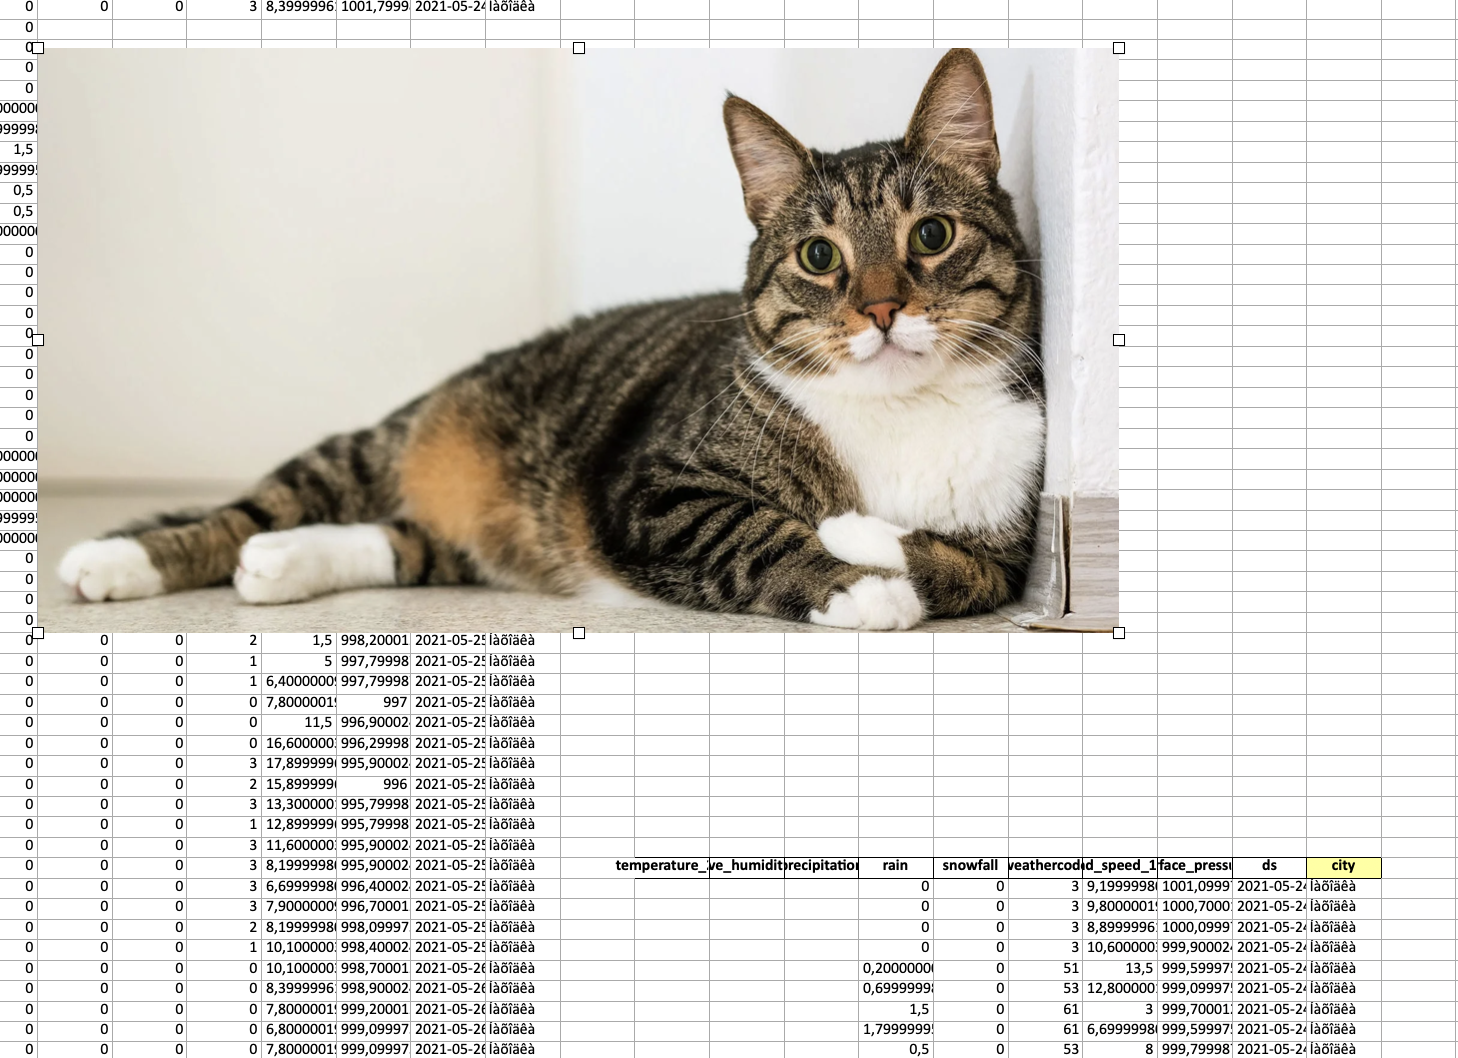

In [33]:
print(all_sheets)

{'Обзор экспорта': Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26], 'Ëèñò1':         temperature_2m  relative_humidity_2m  precipitation  rain  snowfall  \
0             3.800000                    82            0.0   0.0       0.0   
1            -3.000000                    70            0.0   0.0       0.0   
2            -1.300000                    86            0.0   0.0       0.0   
3            19.299999                    49            0.0   0.0       0.0   
4             9.600000                    89            0.0   0.0       0.0   
...                ...                   ...            ...   ...       ...   
125119       24.600000                    57            0.0   0.0       0.0   
125120       22.400000                    44            0.0   0.0       0.0   
125121      -26.000000                    50            0.0   0.0       0.0   
125122       -1.900000                    83   

In [34]:
# маи - это я!
def fix_city_names(df):
    if 'city' not in df.columns:
        return df

    def decode_city(city):
        if not isinstance(city, str):
            return city
        try:
            return city.encode('latin1').decode('cp1251')
        except:
            return city

    df['city'] = df['city'].apply(decode_city)
    return df

def clean_sheet(df, sheet_name):
    if df.empty or len(df.columns) == 0:
        return None

    print(f": {sheet_name} ({df.shape[0]} строк, {df.shape[1]} столбцов)")
    # Удаляем полностью пустые колонки
    columns = df.columns.tolist()
    for column in columns:
      if "Unnamed" in column:
        df.drop(columns=column, inplace=True)


    #  реобразуем ds в datetime
    if 'ds' in df.columns:
        df['ds'] = pd.to_datetime(df['ds'], errors='coerce')

    # Исправляем названия городов
    df = fix_city_names(df)
    return df

Исправили битую кодировку


In [35]:
cleaned_sheets = {}
for name, df in all_sheets.items():
    cleaned = clean_sheet(df, name)
    if cleaned is not None:
        cleaned_sheets[name] = cleaned
print(cleaned_sheets)

: Ëèñò1 (125124 строк, 10 столбцов)
: Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû (125169 строк, 10 столбцов)
: Лист 2 (40 строк, 10 столбцов)
: Лист 1 (107 строк, 10 столбцов)
: Ëèñò3_ñìåøàííûå_òèïû (122736 строк, 10 столбцов)
{'Ëèñò1':         temperature_2m  relative_humidity_2m  precipitation  rain  snowfall  \
0             3.800000                    82            0.0   0.0       0.0   
1            -3.000000                    70            0.0   0.0       0.0   
2            -1.300000                    86            0.0   0.0       0.0   
3            19.299999                    49            0.0   0.0       0.0   
4             9.600000                    89            0.0   0.0       0.0   
...                ...                   ...            ...   ...       ...   
125119       24.600000                    57            0.0   0.0       0.0   
125120       22.400000                    44            0.0   0.0       0.0   
125121      -26.000000                    50            0.0   0.0  

In [36]:
combined_df = pd.concat(cleaned_sheets.values(), ignore_index=True)
len_with_duplicates = len(combined_df)
print(combined_df)

       temperature_2m  relative_humidity_2m precipitation  rain  snowfall  \
0                 3.8                  82.0           0.0   0.0      0.00   
1                -3.0                  70.0           0.0   0.0      0.00   
2                -1.3                  86.0           0.0   0.0      0.00   
3           19.299999                  49.0           0.0   0.0      0.00   
4                 9.6                  89.0           0.0   0.0      0.00   
...               ...                   ...           ...   ...       ...   
373171            2.5                  84.0           0.3   0.2      0.07   
373172            2.6                  79.0           0.1   0.1      0.00   
373173            2.2                  79.0           0.2   0.1      0.07   
373174            1.4                  81.0             0   0.0      0.00   
373175            1.5                  75.0             0   0.0      0.00   

       weathercode wind_speed_10m  surface_pressure                  ds  \


In [37]:
combined_df = combined_df.drop_duplicates()
len_without_duplicates = len(combined_df)
print(len_with_duplicates - len_without_duplicates)

4928


Проверили датасет на дубликаты, их оказалось 4955 строк.

In [38]:
invalid_dates = combined_df['ds'].isna().sum()
print(invalid_dates)
valid = combined_df[pd.to_datetime(combined_df['ds'], errors='coerce').notna()]
invalid = combined_df[pd.to_datetime(combined_df['ds'], errors='coerce').isna()]
valid = valid.set_index('ds').sort_index()
duplicate_index = valid.index.duplicated().sum()
print(duplicate_index)
interes = invalid.notna()
interes.head(32)

32
306848


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city
125131,False,False,False,False,False,False,False,False,False,False
151279,True,True,True,True,True,True,True,True,False,True
151287,True,True,True,True,True,False,True,True,False,False
209110,True,True,True,False,False,False,False,False,False,False
209112,True,True,True,False,False,False,False,False,False,False
209113,True,True,True,False,False,False,False,False,False,False
209114,True,True,True,False,False,False,False,False,False,False
209115,True,True,True,False,False,False,False,False,False,False
209116,True,True,True,False,False,False,False,False,False,False
209117,True,True,True,False,False,False,False,False,False,False


Посмтотрели какие строки с nan временным индексом, они оказались просто

In [39]:
print(valid)

                    temperature_2m  relative_humidity_2m precipitation  rain  \
ds                                                                             
2019-01-01 00:00:00          -13.4                  58.0             0   0.0   
2019-01-01 00:00:00           -6.5                  92.0             0   0.0   
2019-01-01 00:00:00            4.5                  94.0           0.3   0.3   
2019-01-01 00:00:00            4.6                  89.0           0.2   0.2   
2019-01-01 00:00:00          -13.7                  56.0           0.0   0.0   
...                            ...                   ...           ...   ...   
2025-12-31 23:00:00          -22.9                  63.0           0.0   0.0   
2025-12-31 23:00:00           -8.6                  88.0           0.1   0.0   
2025-12-31 23:00:00           -1.4                  80.0           0.0   0.0   
2025-12-31 23:00:00     -16.700001                  49.0             0   0.0   
2025-12-31 23:00:00            1.5      

In [40]:
cities = valid["city"].isna().sum()
unique_cities_count = valid['city'].nunique()
print(cities)
print(unique_cities_count)
unique_cities_list = valid['city'].unique().tolist()
print(f"Список городов: {unique_cities_list}")
map_cities = {'геленджик': 'Геленджик',
              'благовещенск': "Благовещенск",
              'благовещенс': "Благовещенск",
              'благовещенскк': "Благовещенск",
              'геленджикк': 'Геленджик',
              'геленджи': 'Геленджик',
              'москва': 'Москва',
              'мосва': 'Москва',
              'сочи': 'Сочи',
              'сычи': 'Сочи',
              'счи': 'Сочи',
              'соч': 'Сочи'}
def map_city(city):
  if isinstance(city, str):
    city_lower = city.lower()
    if city_lower[0] == "c":
      print(city_lower)
    if city_lower in map_cities:
      return map_cities[city_lower]
    return city
  else:
    print(city)
    return city
valid["city"] = valid["city"].apply(map_city)

3
18
Список городов: ['Находка', 'Москва', 'Геленджик', 'Сочи', 'Благовещенск', 'Санкт-Петербург', 'Мосва', 'БЛАГОВЕЩЕНСК', 'Благовещенскк', 'Благовещенс', 'Геленджи', 'благовещенск', 'Геленджикк', 'геленджик', 'ГЕЛЕНДЖИК', nan, 'Сычи', 'Счи', 'Соч']
nan
nan
nan


In [41]:
Сделали словарь для приведения к единому стандарту городов

SyntaxError: invalid syntax (3745365283.py, line 1)

In [42]:
unique_cities_list = valid['city'].unique().tolist()
print(unique_cities_list)

['Находка', 'Москва', 'Геленджик', 'Сочи', 'Благовещенск', 'Санкт-Петербург', nan]


In [43]:
print(valid[valid["city"].isna()])
valid.dropna(subset=['city'], inplace=True)
unique_cities_list = valid['city'].unique().tolist()
print(unique_cities_list)


                    temperature_2m  relative_humidity_2m precipitation  rain  \
ds                                                                             
2021-12-02 21:00:00           -1.5                  90.0           0.1   0.0   
2021-12-02 22:00:00           -0.9                  92.0           NaN   0.0   
2025-12-31 23:00:00     -16.700001                  49.0             0   0.0   

                     snowfall weathercode wind_speed_10m  surface_pressure  \
ds                                                                           
2021-12-02 21:00:00      0.07        71.0      20.299999        972.400024   
2021-12-02 22:00:00      0.00         3.0      20.200001               NaN   
2025-12-31 23:00:00      0.00           0            9.7       1018.200012   

                    city  
ds                        
2021-12-02 21:00:00  NaN  
2021-12-02 22:00:00  NaN  
2025-12-31 23:00:00  NaN  
['Находка', 'Москва', 'Геленджик', 'Сочи', 'Благовещенск', 'Санкт-Петербу

убрали Nan города, всего 3 записи.

In [44]:
numeric_cols = valid.columns.tolist()[:-1]

for col in numeric_cols:
  nans = valid[col].isna().sum()
  print(f"Пропусков в {col}: {nans}")

Пропусков в temperature_2m: 2565
Пропусков в relative_humidity_2m: 45
Пропусков в precipitation: 2203
Пропусков в rain: 0
Пропусков в snowfall: 0
Пропусков в weathercode: 0
Пропусков в wind_speed_10m: 1577
Пропусков в surface_pressure: 0


Просмотрели количество пропусков в колонках погодных показаний

In [45]:
unique_texts = {}

for col in ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m']:
    mask = pd.to_numeric(valid[col], errors='coerce').isna() & valid[col].notna()
    text_values = valid.loc[mask, col].unique().tolist()
    if text_values:
        unique_texts[col] = text_values

print("Уникальные текстовые значения по колонкам:")
for col, texts in unique_texts.items():
    print(f"\n{col}:")
    for text in texts:
        text = text.encode("latin1").decode('cp1251')
        print(f"  - '{text}'")

Уникальные текстовые значения по колонкам:

temperature_2m:
  - 'холодно'
  - 'нет данных'
  - '---'
  - 'нормально'
  - 'жарко'
  - 'NAN'
  - '?'

precipitation:
  - 'морось'
  - 'сухо'
  - 'NAN'
  - '---'
  - 'нет данных'
  - 'ливень'
  - '?'

wind_speed_10m:
  - 'нет данных'
  - 'ветрено'
  - '?'
  - 'тихо'
  - 'шторм'
  - 'гроза'
  - 'туман'
  - '---'
  - 'NAN'


Просмотрели все текстовые битые значения в численных колонках.

In [46]:
import pandas as pd

def check_date_continuity(df, city_col='city'):
    results = {}
    df_filled = []
    duplic_index = 0
    for city in df[city_col].unique():
        city_data = df[df[city_col] == city]

        dates = city_data.index

        expected_freq = pd.Timedelta(hours=1)

        expected_dates = pd.date_range(
            start=dates.min(),
            end=dates.max(),
            freq=expected_freq
        )

        missing_dates = set(expected_dates) - set(dates)

        duplicate_dates = dates[dates.duplicated()].unique()

        results[city] = {
            'total_expected': len(expected_dates),
            'total_actual': len(dates),
            'missing_count': len(missing_dates),
            'missing_dates': list(missing_dates)[:10],
            'duplicate_count': len(duplicate_dates),
            'duplicate_dates': list(duplicate_dates)[:5],
            'start_date': dates.min(),
            'end_date': dates.max(),
            'frequency': expected_freq
        }
        city_data = city_data.reset_index()
        city_data['ds'] = pd.to_datetime(city_data['ds'], errors='coerce')
        # Удаляем дубликаты по дате
        city_data = city_data.drop_duplicates(subset=['ds'])

        # Устанавливаем индекс обратно
        city_data = city_data.set_index('ds').sort_index()

        city_data_full = city_data.reindex(expected_dates)
        city_data_full[city_col] = city
        df_filled.append(city_data_full)

    return results, pd.concat(df_filled)


continuity_results, df_filled = check_date_continuity(valid)

for city in valid["city"].unique():
    print(city)
    print(continuity_results[city])



Находка
{'total_expected': 61367, 'total_actual': 61377, 'missing_count': 0, 'missing_dates': [], 'duplicate_count': 10, 'duplicate_dates': [Timestamp('2021-05-25 08:00:00'), Timestamp('2021-05-25 09:00:00'), Timestamp('2021-05-25 10:00:00'), Timestamp('2021-05-25 11:00:00'), Timestamp('2021-05-25 12:00:00')], 'start_date': Timestamp('2019-01-01 00:00:00'), 'end_date': Timestamp('2025-12-31 22:00:00'), 'frequency': Timedelta('0 days 01:00:00')}
Москва
{'total_expected': 61368, 'total_actual': 61364, 'missing_count': 4, 'missing_dates': [Timestamp('2021-12-03 13:00:00'), Timestamp('2021-12-02 21:00:00'), Timestamp('2021-12-03 05:00:00'), Timestamp('2021-12-02 22:00:00')], 'duplicate_count': 0, 'duplicate_dates': [], 'start_date': Timestamp('2019-01-01 00:00:00'), 'end_date': Timestamp('2025-12-31 23:00:00'), 'frequency': Timedelta('0 days 01:00:00')}
Геленджик
{'total_expected': 61368, 'total_actual': 61368, 'missing_count': 0, 'missing_dates': [], 'duplicate_count': 0, 'duplicate_dates

Посмотрели TimeRange по каждому городу и сколько дат из него выпадает, добавили недостающие временные индексы с nan во всех других колонках, кроме city

In [47]:

def auto_fill_missing(df, col, city_col='city'):
    df_filled = df.copy()

    df_filled[col] = pd.to_numeric(df_filled[col], errors='coerce')


    cities = df_filled[city_col].unique()
    print(f"Найдено городов: {len(cities)}")

    for city in cities:
        city_mask = df_filled[city_col] == city
        city_series = df_filled.loc[city_mask, col]

        missing_count = city_series.isnull().sum()

        if missing_count == 0:
            print(f"\n{city}: пропусков нет")
            continue

        # Находим максимальную длину непрерывного пропуска
        is_na = city_series.isnull().astype(int)
        groups = (is_na != is_na.shift()).cumsum()

        run_lengths = city_series.groupby(groups).size()
        na_run_lengths = run_lengths[city_series.groupby(groups).first().isnull()]

        max_run = na_run_lengths.max() if len(na_run_lengths) > 0 else 0
        missing_pct = missing_count / len(city_series) * 100

        print(f"{city}:")
        print(f"Пропусков: {missing_count} ({missing_pct:.1f}%)")
        print(f"Макс. длина пропуска: {max_run}")

        # Выбираем метод
        if max_run == 1:
            filled = city_series.ffill().bfill()
            df_filled.loc[city_mask, col] = filled
            print(f"ffill/bfill (одиночные пропуски)")

        elif max_run <= 5:
            filled = city_series.interpolate(method='linear', limit_direction='both')
            df_filled.loc[city_mask, col] = filled
            print(f"линейная интерполяция (макс. {max_run})")

        elif max_run <= 24:
            rolling_mean = city_series.rolling(window=7, min_periods=1).mean()
            filled = city_series.fillna(rolling_mean)
            df_filled.loc[city_mask, col] = filled
            print(f"скользящее среднее (окно 7)")

        else:
            city_median = city_series.median()
            filled = city_series.fillna(city_median)
            df_filled.loc[city_mask, col] = filled
            print(f"медиана по городу (длинный пропуск)")

    # Финальная очистка
    remaining = df_filled[col].isnull().sum()
    if remaining > 0:
        overall_median = df_filled[col].median()
        df_filled[col] = df_filled[col].fillna(overall_median)
        print(f"Финально: заполнено общей медианой {remaining} пропусков")

    return df_filled


# Применяем
df_clean = valid.copy()
# Применяем
# 'õîëîäíî' - холодно
df_clean = valid.copy()
df_clean = auto_fill_missing(df_clean, 'temperature_2m')
df_clean = auto_fill_missing(df_clean, 'relative_humidity_2m')
df_clean = auto_fill_missing(df_clean, 'precipitation')
df_clean = auto_fill_missing(df_clean, 'wind_speed_10m')

Найдено городов: 6
Находка:
Пропусков: 653 (1.1%)
Макс. длина пропуска: 31
медиана по городу (длинный пропуск)
Москва:
Пропусков: 604 (1.0%)
Макс. длина пропуска: 2
линейная интерполяция (макс. 2)
Геленджик:
Пропусков: 927 (1.5%)
Макс. длина пропуска: 2
линейная интерполяция (макс. 2)
Сочи:
Пропусков: 610 (1.0%)
Макс. длина пропуска: 2
линейная интерполяция (макс. 2)
Благовещенск:
Пропусков: 914 (1.5%)
Макс. длина пропуска: 2
линейная интерполяция (макс. 2)
Санкт-Петербург:
Пропусков: 622 (1.0%)
Макс. длина пропуска: 5
линейная интерполяция (макс. 5)
Найдено городов: 6
Находка:
Пропусков: 40 (0.1%)
Макс. длина пропуска: 31
медиана по городу (длинный пропуск)

Москва: пропусков нет

Геленджик: пропусков нет

Сочи: пропусков нет

Благовещенск: пропусков нет
Санкт-Петербург:
Пропусков: 5 (0.0%)
Макс. длина пропуска: 5
линейная интерполяция (макс. 5)
Найдено городов: 6
Находка:
Пропусков: 645 (1.1%)
Макс. длина пропуска: 31
медиана по городу (длинный пропуск)
Москва:
Пропусков: 619 (1.0%)


In [48]:
numeric_cols = df_clean.columns.tolist()[:-1]

for col in numeric_cols:
  nans = df_clean[col].isna().sum()
  print(f"Пропусков в {col}: {nans}")
  if col == "relative_humidity_2m":
    print(df_clean[df_clean[col].isna()])

Пропусков в temperature_2m: 0
Пропусков в relative_humidity_2m: 0
Empty DataFrame
Columns: [temperature_2m, relative_humidity_2m, precipitation, rain, snowfall, weathercode, wind_speed_10m, surface_pressure, city]
Index: []
Пропусков в precipitation: 0
Пропусков в rain: 0
Пропусков в snowfall: 0
Пропусков в weathercode: 0
Пропусков в wind_speed_10m: 0
Пропусков в surface_pressure: 0


In [49]:
df_clean.head()

,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,city
ds,,,,,,,,,
2019-01-01,-13.4,58.0,0.0,0.0,0.0,0.0,5.2,1025.500000,Находка
2019-01-01,-6.5,92.0,0.0,0.0,0.0,3.0,10.8,1000.500000,Москва
2019-01-01,4.5,94.0,0.3,0.3,0.0,51,5.5,1023.200012,Геленджик
2019-01-01,4.6,89.0,0.2,0.2,0.0,51,8.0,1024.699951,Сочи
2019-01-01,-13.7,56.0,0.0,0.0,0.0,3,12.6,1008.700012,Благовещенск


In [50]:
import pandas as pd
import numpy as np


def remove_outliers_by_city_month(df, col, city_col='city'):
    """
    Удаление выбросов по городу и месяцу
    """
    df_clean = df.copy()


    if not isinstance(df_clean.index, pd.DatetimeIndex):
        if 'ds' in df_clean.columns:
            df_clean['ds'] = pd.to_datetime(df_clean['ds'])
            df_clean = df_clean.set_index('ds')
        else:
            raise ValueError("Нет колонки с датами!")

    # Добавляем месяц
    df_clean['month'] = df_clean.index.month

    print(f"\n{col}:")

    for city in df_clean[city_col].unique():
        for month in range(1, 13):
            mask = (df_clean[city_col] == city) & (df_clean['month'] == month)
            city_month_data = df_clean.loc[mask, col].dropna()



            # IQR
            Q1 = city_month_data.quantile(0.25)
            Q3 = city_month_data.quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR

            outliers = ((city_month_data < lower) | (city_month_data > upper)).sum()

            if outliers > 0:
                df_clean.loc[mask, col] = df_clean.loc[mask, col].clip(lower, upper)
                print(f"  {city} - месяц {month}: {outliers} выбросов")

    df_clean = df_clean.drop('month', axis=1)
    return df_clean





In [59]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

def process_weathercode(df):
    """
    Обработка weathercode как категориальной переменной
    """
    df_clean = df.copy()

    # Преобразование в числа
    df_clean['weathercode'] = pd.to_numeric(df_clean['weathercode'], errors='coerce')

    # Валидные коды WMO
    valid_codes = set(range(0, 100))
    invalid_mask = ~df_clean['weathercode'].isin(valid_codes) & df_clean['weathercode'].notna()

    if invalid_mask.any():
        print(f"  Невалидных кодов: {invalid_mask.sum()}")
        df_clean.loc[invalid_mask, 'weathercode'] = np.nan


    for city in df_clean['city'].unique():
        city_codes = df_clean[df_clean['city'] == city]['weathercode'].dropna()
        if len(city_codes) > 0:
            mode_val = city_codes.mode()
            if len(mode_val) > 0:
                mode_val = mode_val.iloc[0]
                mask = (df_clean['city'] == city) & (df_clean['weathercode'].isna())
                df_clean.loc[mask, 'weathercode'] = mode_val


    if df_clean['weathercode'].isna().any():
        global_mode = df_clean['weathercode'].mode()
        if len(global_mode) > 0:
            df_clean['weathercode'] = df_clean['weathercode'].fillna(global_mode.iloc[0])

    print(f"  Пропусков после обработки: {df_clean['weathercode'].isna().sum()}")
    return df_clean


def add_month_column(df):
    """Добавляет колонку месяца из индекса"""
    df_clean = df.copy()
    if not isinstance(df_clean.index, pd.DatetimeIndex):
        if 'ds' in df_clean.columns:
            df_clean['ds'] = pd.to_datetime(df_clean['ds'])
            df_clean = df_clean.set_index('ds')
    df_clean['month'] = df_clean.index.month
    return df_clean


def remove_outliers_by_city_month(df, col, iqr_multiplier=1.5):
    """
    Удаление выбросов по городу и месяцу методом IQR
    """
    df_clean = df.copy()
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    df_clean = add_month_column(df_clean)
    total_outliers = 0

    for city in df_clean['city'].unique():
        for month in range(1, 13):
            mask = (df_clean['city'] == city) & (df_clean['month'] == month)
            data = df_clean.loc[mask, col].dropna()

            if len(data) < 5:
                continue

            Q1 = data.quantile(0.25)
            Q3 = data.quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - iqr_multiplier * IQR
            upper = Q3 + iqr_multiplier * IQR

            if col == 'relative_humidity_2m':
                lower = max(lower, 0)
                upper = min(upper, 100)
            elif col in ['wind_speed_10m', 'precipitation', 'rain', 'snowfall']:
                lower = max(lower, 0)

            outliers = ((data < lower) | (data > upper)).sum()
            if outliers > 0:
                df_clean.loc[mask, col] = df_clean.loc[mask, col].clip(lower, upper)
                total_outliers += outliers

    df_clean = df_clean.drop('month', axis=1)
    print(f"  {col}: обработано {total_outliers} выбросов")
    return df_clean


def process_precipitation(df):
    """
    Специальная обработка осадков
    """
    df_clean = df.copy()
    df_clean['precipitation'] = pd.to_numeric(df_clean['precipitation'], errors='coerce')
    df_clean = add_month_column(df_clean)
    total_capped = 0


    for city in df_clean['city'].unique():
        for month in range(1, 13):
            mask = (df_clean['city'] == city) & (df_clean['month'] == month)
            data = df_clean.loc[mask, 'precipitation'].dropna()

            if len(data) < 10:
                continue

            upper = data.quantile(0.995)
            lower = 0
            physical_max = 200
            final_upper = min(upper, physical_max)
            outliers = (data > final_upper).sum()

            if outliers > 0:
                df_clean.loc[mask, 'precipitation'] = df_clean.loc[mask, 'precipitation'].clip(lower, final_upper)
                total_capped += outliers

    df_clean.loc[df_clean['precipitation'] > 200, 'precipitation'] = 200
    df_clean.loc[df_clean['precipitation'] < 0, 'precipitation'] = 0
    df_clean = df_clean.drop('month', axis=1)

    df_clean['precipitation'] = df_clean.groupby('city')['precipitation'].transform(
        lambda x: x.fillna(x.median())
    )

    print(f"Ограничено значений: {total_capped}")
    return df_clean


def process_numeric_column(df, col):
    """Общая обработка числовой колонки"""
    df_clean = df.copy()
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    df_clean[col] = df_clean.groupby('city')[col].transform(lambda x: x.fillna(x.median()))

    if col == 'temperature_2m':
        df_clean = remove_outliers_by_city_month(df_clean, col, iqr_multiplier=1.5)
    elif col == 'wind_speed_10m':
        df_clean = remove_outliers_by_city_month(df_clean, col, iqr_multiplier=2.5)
    elif col == 'surface_pressure':
        df_clean = remove_outliers_by_city_month(df_clean, col, iqr_multiplier=2.0)
    elif col == 'relative_humidity_2m':
        df_clean = remove_outliers_by_city_month(df_clean, col, iqr_multiplier=1.5)
    elif col in ['rain', 'snowfall']:
        df_clean[col] = df_clean[col].clip(lower=0)

    return df_clean


def process_numeric_column(df, col):
    """Общая обработка числовой колонки"""
    df_clean = df.copy()
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    df_clean[col] = df_clean.groupby('city')[col].transform(lambda x: x.fillna(x.median()))

    if col == 'temperature_2m':
        df_clean = remove_outliers_by_city_month(df_clean, col, iqr_multiplier=1.5)
    elif col == 'wind_speed_10m':
        df_clean = remove_outliers_by_city_month(df_clean, col, iqr_multiplier=2.5)
    elif col == 'surface_pressure':
        df_clean = remove_outliers_by_city_month(df_clean, col, iqr_multiplier=2.0)
    elif col == 'relative_humidity_2m':
        df_clean = remove_outliers_by_city_month(df_clean, col, iqr_multiplier=1.5)
    elif col in ['rain', 'snowfall']:
        df_clean[col] = df_clean[col].clip(lower=0)
        # Добавляем вывод информации
        print(f" {col}: заполнено пропусков медианой, clip(lower=0)")
        print(f"  медиана: {df_clean[col].median():.4f}")
        print(f"  max: {df_clean[col].max():.4f}")

    return df_clean


# Применение
df_final = process_all_columns(df_filled)

ОБРАБОТКА ДАННЫХ

temperature_2m:
  temperature_2m: обработано 4918 выбросов

relative_humidity_2m:
  relative_humidity_2m: обработано 2683 выбросов

wind_speed_10m:
  wind_speed_10m: обработано 1364 выбросов

surface_pressure:
  surface_pressure: обработано 1267 выбросов

rain:
 rain: заполнено пропусков медианой, clip(lower=0)
  медиана: 0.0000
  max: 27.1000

snowfall:
 snowfall: заполнено пропусков медианой, clip(lower=0)
  медиана: 0.0000
  max: 4.6200
Ограничено значений: 1820

weathercode:
  Пропусков после обработки: 0

ФИНАЛЬНАЯ ПРОВЕРКА
  temperature_2m: 0 пропусков
  relative_humidity_2m: 0 пропусков
  wind_speed_10m: 0 пропусков
  surface_pressure: 0 пропусков
  rain: 0 пропусков
  snowfall: 0 пропусков
  precipitation: 0 пропусков
  weathercode: 0 пропусков


Обрабатываем пропуски методом в зависимости от длины пропуска. Сомотрим выбросы отдельно по городу и месяцу

array([<Axes: xlabel='ds'>, <Axes: xlabel='ds'>, <Axes: xlabel='ds'>,
       <Axes: xlabel='ds'>, <Axes: xlabel='ds'>, <Axes: xlabel='ds'>,
       <Axes: xlabel='ds'>], dtype=object)

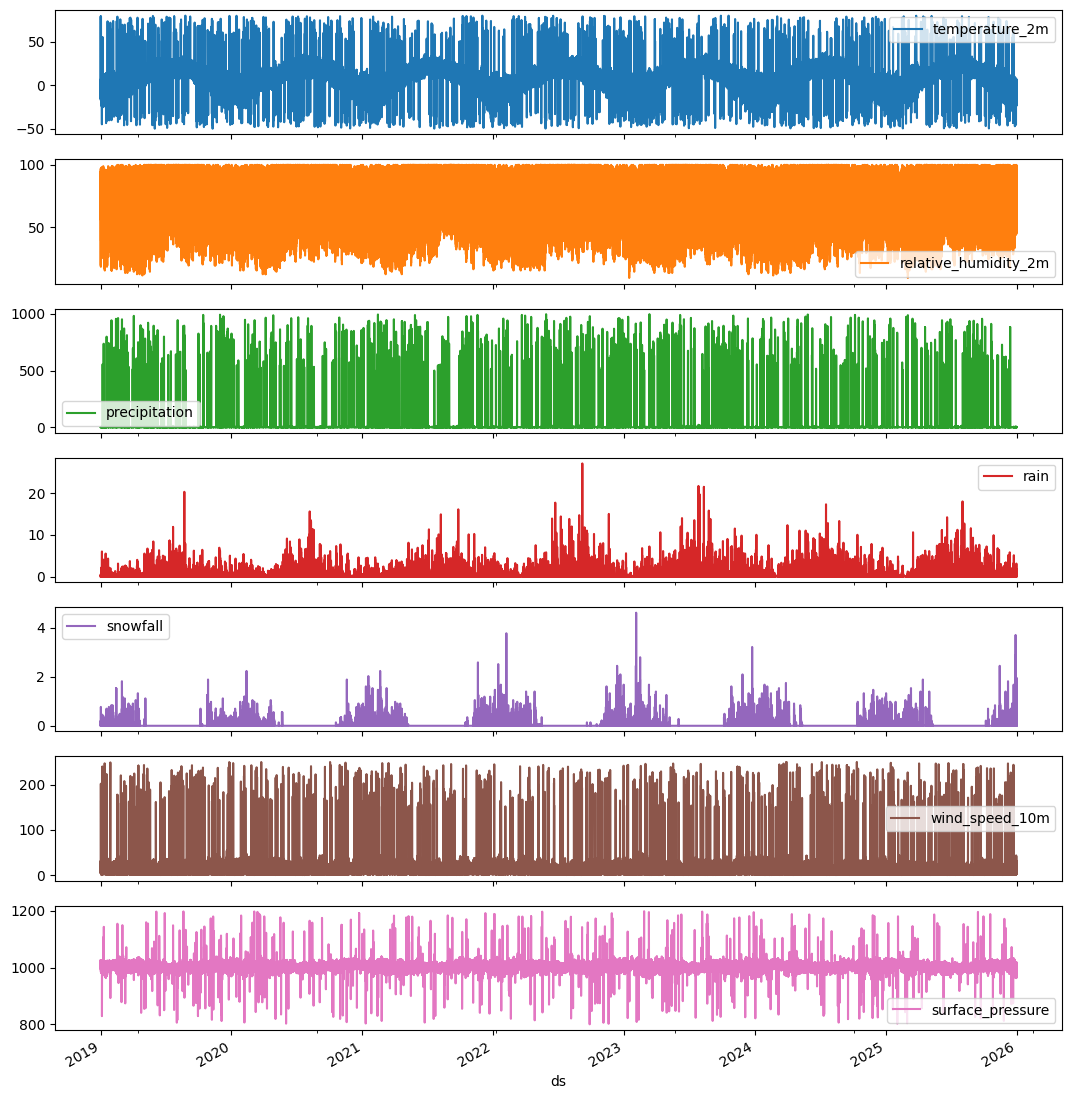

In [57]:
df_clean.plot(subplots=True, figsize=(13,15))